In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random as rd

In [102]:
df = pd.read_csv('datasets/diamonds-prices-2022.csv')

In [103]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 53943
Columns: 11


In [104]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [105]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [106]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,26972.000000,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,15572.147122,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13486.500000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26972.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40457.500000,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,53943.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [108]:
df.duplicated().sum()

0

## Section I: Preprocessing

In [109]:
# Remove unnecessary features and move some features to better locations for easier data extraction

price_col = df['price'].copy()

df.drop('Unnamed: 0', axis=1, inplace=True)
df.drop('price', axis=1, inplace=True)

df = pd.concat([df, price_col], axis=1)

df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [110]:
# Extract a numeric copy of the dataset and check skew

skew_df = df.select_dtypes(include='number').copy()

skew_df.skew()

carat    1.116705
depth   -0.082187
table    0.796836
x        0.378685
y        2.434233
z        1.522481
price    1.618476
dtype: float64

In [111]:
# Make a function to handle skew
from pandas.api.types import is_numeric_dtype

left_skewed_cols = []
right_skewed_cols = ['carat', 'y', 'z', 'price']

def logify(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    for col in data.columns:
        if not is_numeric_dtype(data[col].dtype):
            continue
        if data[col].skew() > 1:
            data[col] = np.log1p(data[col])
        elif data[col].skew() < -1:
            reflected = data[col].max() + 1 - data[col]
            data[col] = np.log1p(reflected)
    return data

def unlogify(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    for col in data.columns:
        if not is_numeric_dtype(data[col].dtype):
            continue
        if col in right_skewed_cols:
            data[col] = np.expm1(data[col])
    return data

In [112]:
# For all columns with a skew > 1 or < -1 log transform them - skew handling

df = logify(df)
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.207014,Ideal,E,SI2,61.5,55.0,3.95,1.605430,1.232560,5.789960
1,0.190620,Premium,E,SI1,59.8,61.0,3.89,1.576915,1.196948,5.789960
2,0.207014,Good,E,VS1,56.9,65.0,4.05,1.623341,1.196948,5.793014
3,0.254642,Premium,I,VS2,62.4,58.0,4.20,1.654411,1.289233,5.814131
4,0.270027,Good,J,SI2,63.3,58.0,4.34,1.677097,1.321756,5.817111


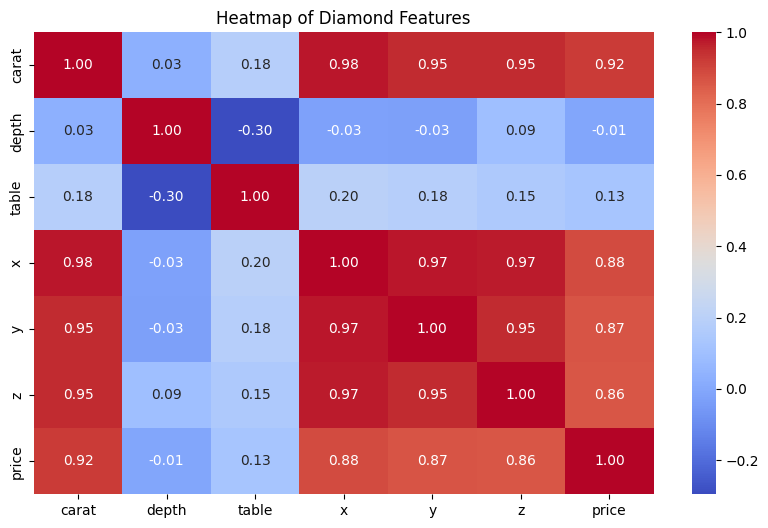

In [113]:
# Check colinearity of columns

_corr = skew_df.corr()

plt.figure(figsize=(10, 6))
plt.title('Heatmap of Diamond Features')
sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

**NOTE: the carat, x, y, and z columns seem highly colinear - carat is just the size of the diamond, so this is expected**

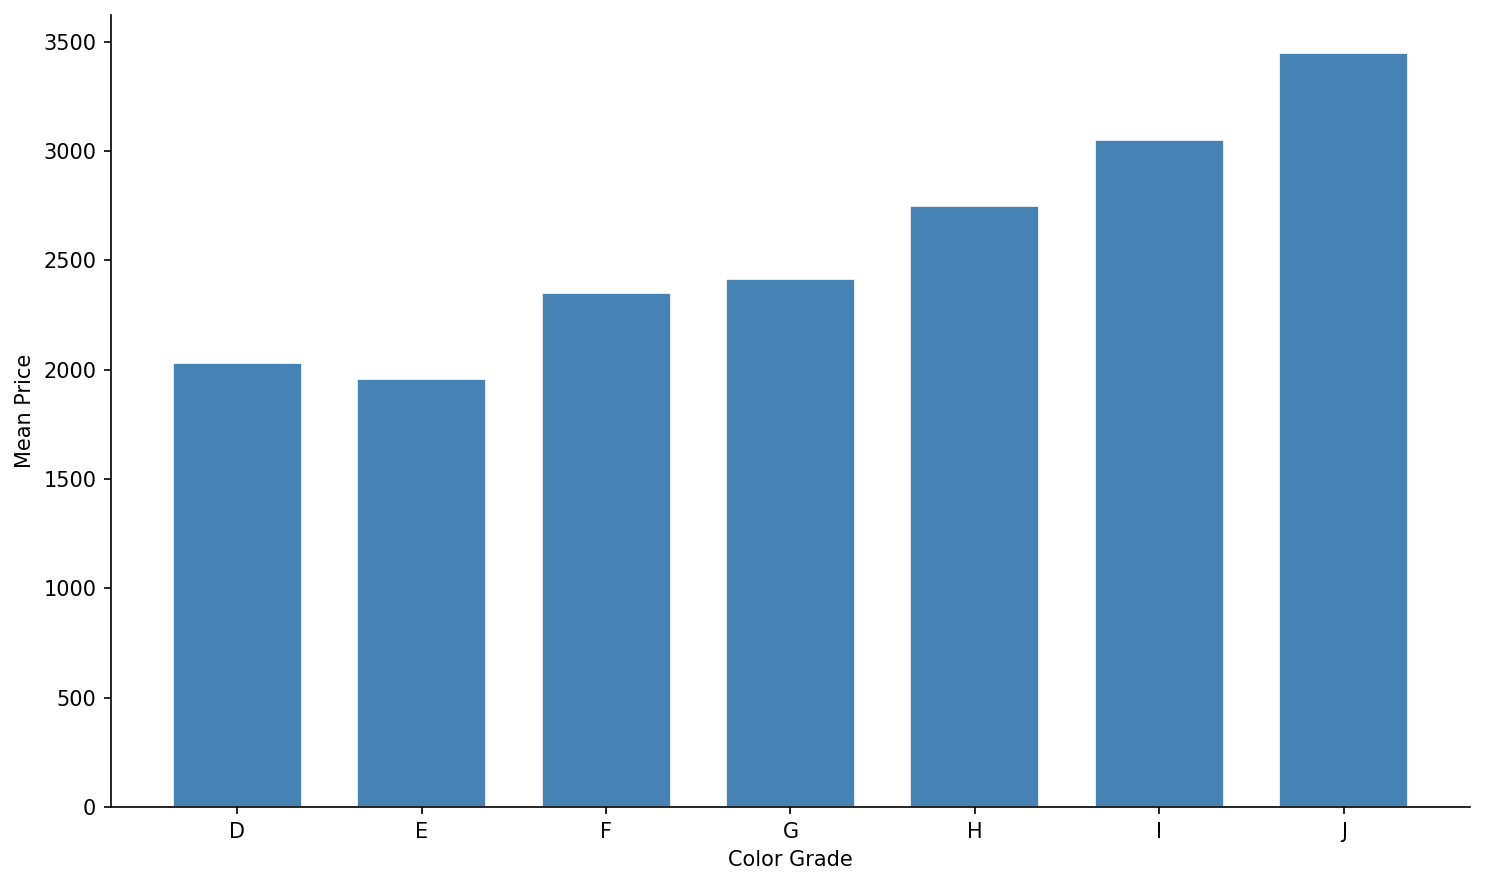

In [114]:
import os

output_dir = "/home/huzaifa/Downloads/img"  # edit this
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

price_by_color = df.groupby("color")["price"].mean()
order = ["D", "E", "F", "G", "H", "I", "J"]
price_by_color = price_by_color.reindex(order)

ax.bar(
    price_by_color.index,
    np.expm1(price_by_color.values),
    color="steelblue",
    edgecolor="white",
    linewidth=0.8,
    width=0.7,
)

ax.set_title("")
ax.set_xlabel("Color Grade")
ax.set_ylabel("Mean Price")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "mean_price_by_color.png"),
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

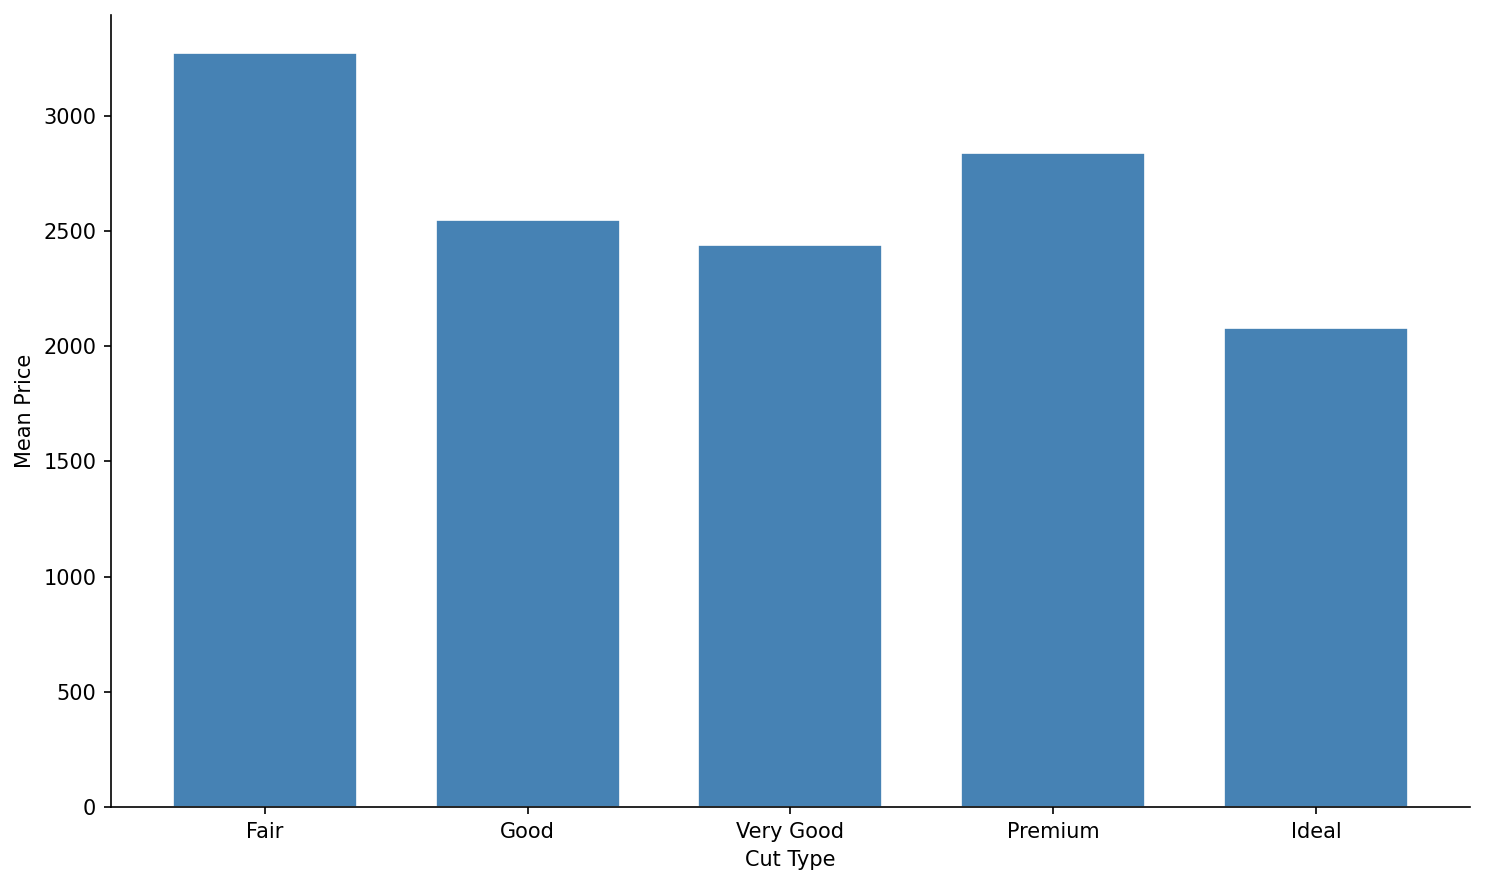

In [115]:
import os

output_dir = "/home/huzaifa/Downloads/img"
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

price_by_cut = df.groupby("cut")["price"].mean()
order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
price_by_cut = price_by_cut.reindex(order)

ax.bar(
    price_by_cut.index,
    np.expm1(price_by_cut.values),
    color="steelblue",
    edgecolor="white",
    linewidth=0.8,
    width=0.7,
)

ax.set_title("")
ax.set_xlabel("Cut Type")
ax.set_ylabel("Mean Price")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "mean_price_by_cut.png"),
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

**NOTE: A worse cut suggests a higher price due to higher mean carat**

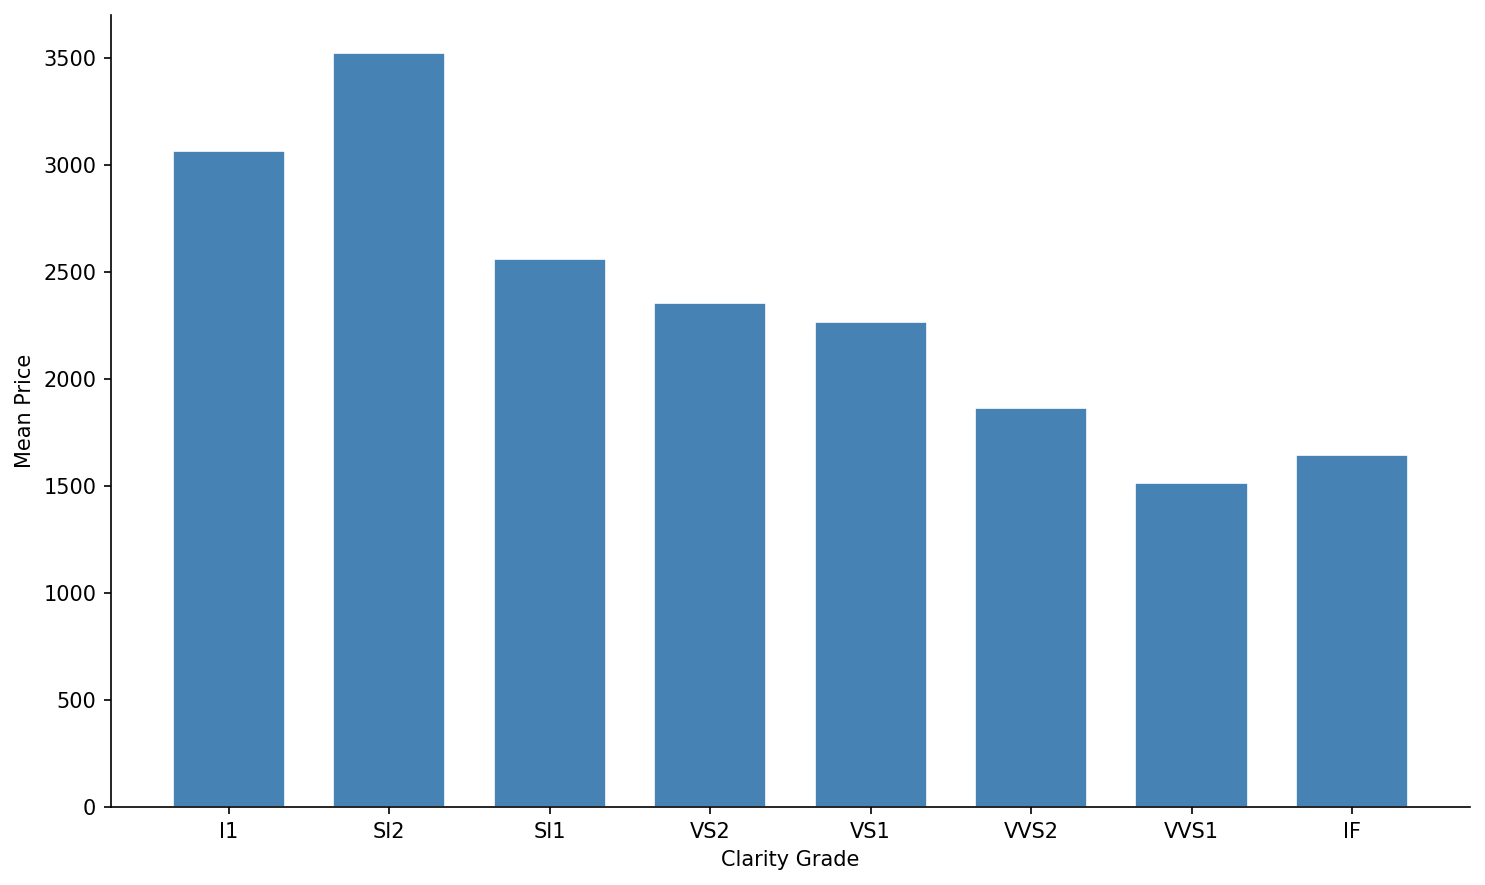

In [116]:
import os

output_dir = "/home/huzaifa/Downloads/img"
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

price_by_clarity = df.groupby("clarity")["price"].mean()
order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
price_by_clarity = price_by_clarity.reindex(order)

ax.bar(
    price_by_clarity.index,
    np.expm1(price_by_clarity.values),
    color="steelblue",
    edgecolor="white",
    linewidth=0.8,
    width=0.7,
)

ax.set_title("")
ax.set_xlabel("Clarity Grade")
ax.set_ylabel("Mean Price")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "mean_price_by_clarity.png"),
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

**NOTE: The best clarity doesn't directly correlate with best height either - since it largely depends on carat and some lower clarities have the highest carats**

## Section II: Model Application Preprocessing

In [117]:
# Extract the dataset

X = df.copy()
X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.207014,Ideal,E,SI2,61.5,55.0,3.95,1.605430,1.232560,5.789960
1,0.190620,Premium,E,SI1,59.8,61.0,3.89,1.576915,1.196948,5.789960
2,0.207014,Good,E,VS1,56.9,65.0,4.05,1.623341,1.196948,5.793014
3,0.254642,Premium,I,VS2,62.4,58.0,4.20,1.654411,1.289233,5.814131
4,0.270027,Good,J,SI2,63.3,58.0,4.34,1.677097,1.321756,5.817111


In [118]:
# Encode the dataset 

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    ['D', 'E', 'F', 'G', 'H', 'I', 'J'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
])

cols = ['cut', 'color', 'clarity']
X[cols] = oe.fit_transform(X[cols])

X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.207014,4.0,1.0,1.0,61.5,55.0,3.95,1.605430,1.232560,5.789960
1,0.190620,3.0,1.0,2.0,59.8,61.0,3.89,1.576915,1.196948,5.789960
2,0.207014,1.0,1.0,4.0,56.9,65.0,4.05,1.623341,1.196948,5.793014
3,0.254642,3.0,5.0,3.0,62.4,58.0,4.20,1.654411,1.289233,5.814131
4,0.270027,1.0,6.0,1.0,63.3,58.0,4.34,1.677097,1.321756,5.817111


In [119]:
# Scale the dataset 

from sklearn.preprocessing import StandardScaler

price_col_temp = X.pop('price')

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

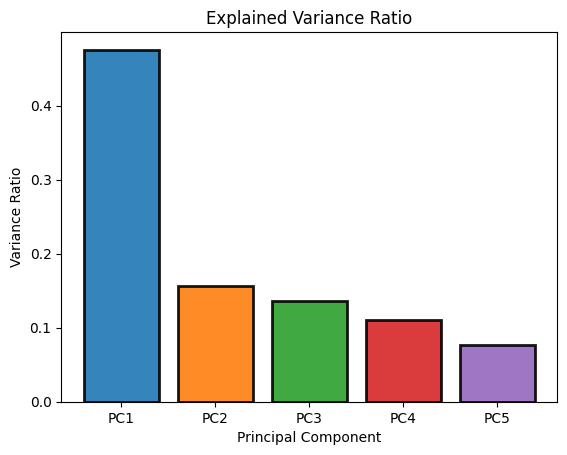

In [120]:
# Convert into principal components before clustering

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

pc_num = X_pca.shape[1]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:pc_num]

plt.title('Explained Variance Ratio')
plt.bar(['PC' + str(_+1) for _ in range(pc_num)], pca.explained_variance_ratio_, 
    color=colors, linewidth=2, edgecolor='black', alpha=0.9)

plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.show()

In [121]:
# Make a loadings DataFrame for easier analysis

loadings = pd.DataFrame(data=pca.components_, columns=X.columns, index=['PC' + str(_+1) for _ in range(X_pca.shape[1])])
loadings.head()

,carat,cut,color,clarity,depth,table,x,y,z
PC1,0.473945,-0.111052,0.154039,-0.225978,0.012783,0.130313,0.475812,0.473302,0.469780
PC2,-0.086509,-0.604045,-0.197627,-0.206168,-0.192002,0.695351,-0.083969,-0.084767,-0.107098
PC3,-0.030022,-0.441615,-0.017535,-0.205146,0.832734,-0.237184,-0.075791,-0.074045,0.027462
PC4,-0.016643,-0.227174,0.813233,0.495399,0.063696,0.180849,-0.034045,-0.045319,-0.037025
PC5,0.117762,-0.179103,-0.523487,0.786384,0.115918,0.025663,0.113217,0.123102,0.139810


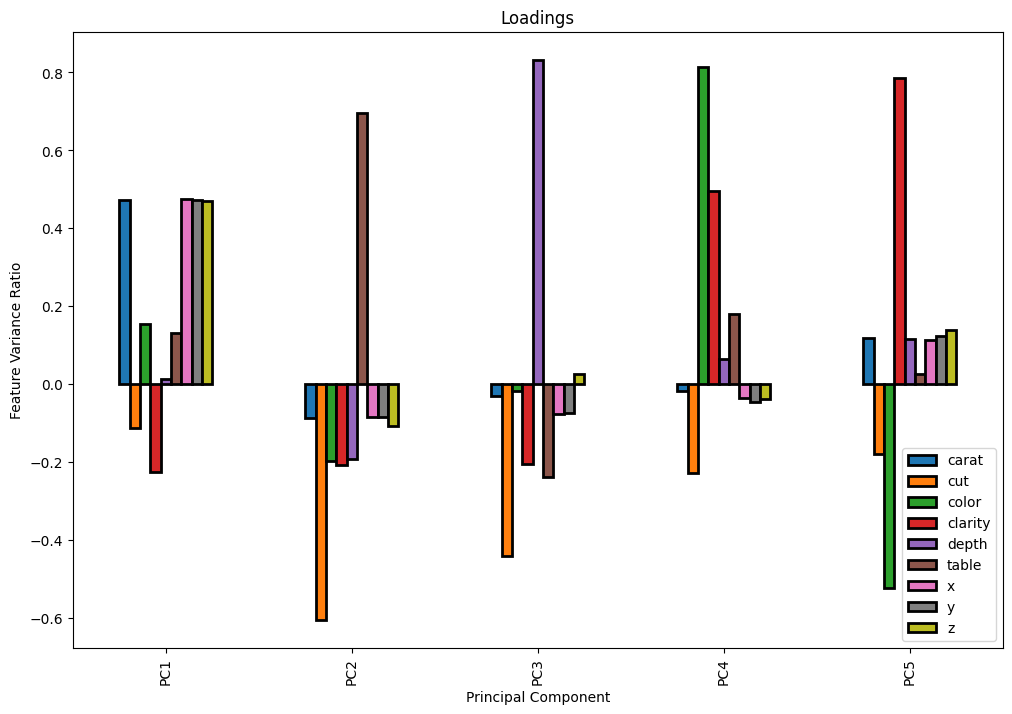

In [122]:
# Plot loadings

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:loadings.shape[1]]

fig, ax = plt.subplots(figsize=(12, 8))

loadings.plot(
    kind='bar',
    stacked=False,
    color=colors,
    edgecolor='black',
    linewidth=2,
    ax=ax
)

ax.set_title('Loadings')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature Variance Ratio')

plt.show()

## Section III: Model Application

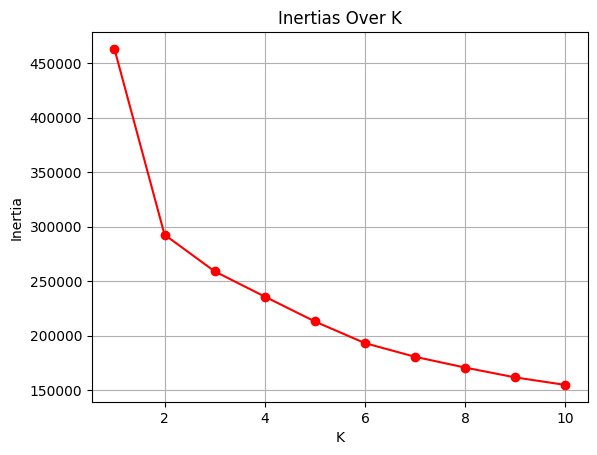

In [123]:
# Find optimal value of 'k' for KMeans

from sklearn.cluster import KMeans

inertias = []
ks = [k for k in range(1, 11)]
for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit_transform(X_pca)
    inertias.append(km.inertia_)

plt.title('Inertias Over K')
plt.plot(ks, inertias, color='red', marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')

plt.grid(True)
plt.show()

**NOTE: We'll set the value of k to be 4**

In [124]:
km = KMeans(n_clusters=4, random_state=42)
X_km = km.fit_transform(X_scaled)

labels = km.labels_

X['price'] = price_col_temp
X['cluster'] = labels

X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,cluster
0,0.207014,4.0,1.0,1.0,61.5,55.0,3.95,1.605430,1.232560,5.789960,1
1,0.190620,3.0,1.0,2.0,59.8,61.0,3.89,1.576915,1.196948,5.789960,1
2,0.207014,1.0,1.0,4.0,56.9,65.0,4.05,1.623341,1.196948,5.793014,1
3,0.254642,3.0,5.0,3.0,62.4,58.0,4.20,1.654411,1.289233,5.814131,1
4,0.270027,1.0,6.0,1.0,63.3,58.0,4.34,1.677097,1.321756,5.817111,1


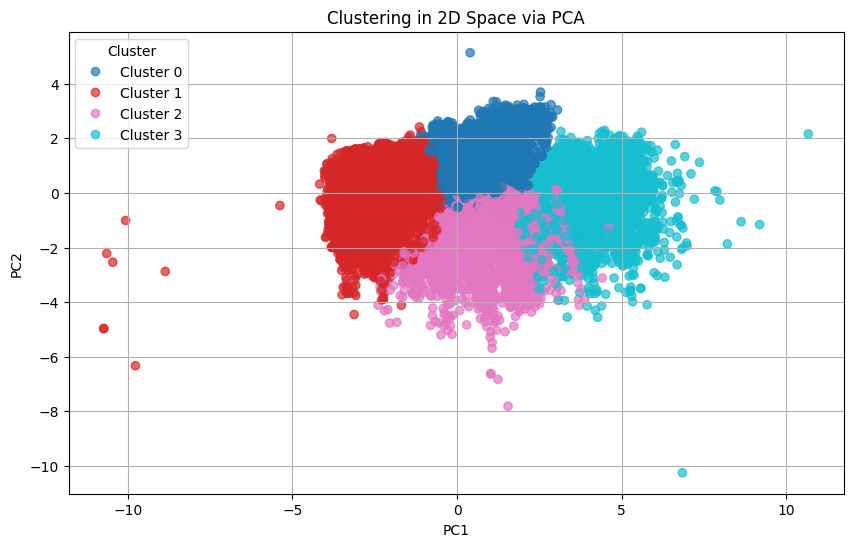

In [125]:
from matplotlib.lines import Line2D

# Find the clustering done in 2D space

# STEP 1: Rescale

ss = StandardScaler()
X_cluster_scaled = ss.fit_transform(X)

# STEP 2: Plot clusters in 2D space 

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_cluster_scaled)


plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.7
)

plt.title('Clustering in 2D Space via PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i}' for i in sorted(np.unique(labels))], title='Cluster' )

plt.grid(True)
plt.show()

In [126]:
# Untransorm the dataset

# STEP 0: Reverse the log transform
X = unlogify(X)
X.head()

# STEP 1: Reverse the OrdinalEncoding
cols = ['cut', 'color', 'clarity']
X[cols] = oe.inverse_transform(X[cols])

X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,cluster
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326.0,1
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326.0,1
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327.0,1
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334.0,1
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335.0,1


In [127]:
# Separate features by numerical and categorical

num_cols = []
cat_cols = []

for col in X.columns:
    if is_numeric_dtype(X[col]):
        num_cols.append(col)
    else:
        cat_cols.append(col)

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['carat', 'depth', 'table', 'x', 'y', 'z', 'price', 'cluster']
Categorical columns: ['cut', 'color', 'clarity']


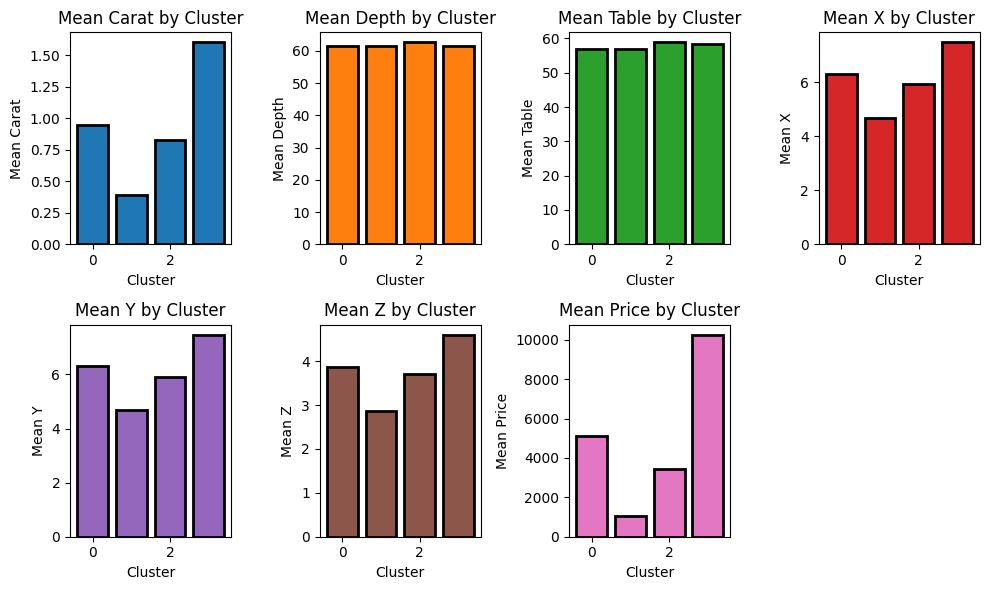

In [128]:
# Analyze the categorical columns per cluster

num_cols = num_cols[:-1]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(num_cols)]

fig, ax = plt.subplots(2, 4, figsize=(10, 6))

for idx, col in enumerate(num_cols):
    r = idx // 4
    c = idx % 4

    mean_metric = X.groupby('cluster')[col].mean()
    
    ax[r][c].bar(mean_metric.index, mean_metric.values, color=colors[idx], linewidth=2, edgecolor='black')
    ax[r][c].set_title(f'Mean {col.title()} by Cluster')
    ax[r][c].set_xlabel('Cluster')
    ax[r][c].set_ylabel(f'Mean {(col.title())}')

plt.delaxes(ax[1][3])
plt.tight_layout()
plt.show()


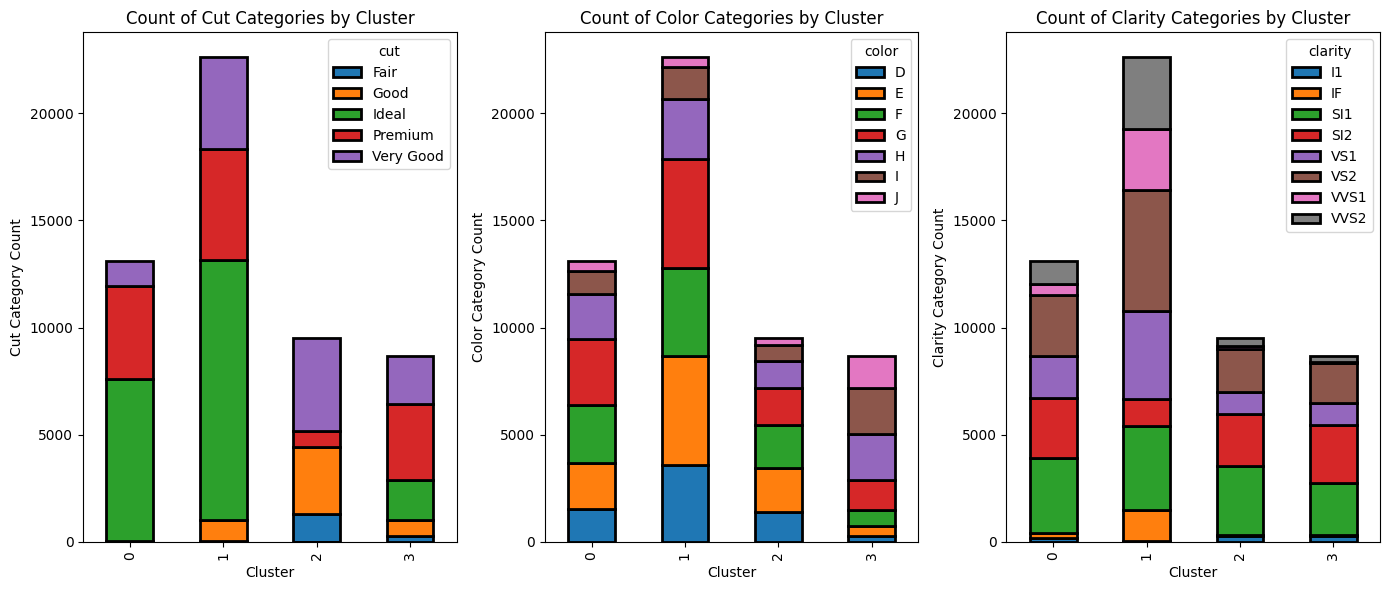

In [129]:
# Count of category for each cluster

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

for idx, col in enumerate(cat_cols):
    color_len = len(np.unique(X[col]))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:color_len]

    cluster_counts_per_category = X.groupby('cluster')[col].value_counts().unstack(fill_value=0)

    cluster_counts_per_category.plot(kind='bar', stacked=True, color=colors, linewidth=2, edgecolor='black', ax=ax[idx])
    ax[idx].set_title(f'Count of {col.title()} Categories by Cluster')
    ax[idx].set_xlabel(f'Cluster')
    ax[idx].set_ylabel(f'{(col.title())} Category Count')

plt.tight_layout()
plt.show()


In [130]:
# Make a copy of X 

X_clusters = X.copy()

In [131]:
# Add description category for each cluster

description_category = {
    0: 'Medium, Mixed Cut, Mixed Color',
    1: 'Small, Ideal Cut, Near-Colorless',
    2: 'Medium, Very Good Cut, Mixed Color',
    3: 'Large, Premium Cut, Lower Color'
}

X['diamond_description'] = X['cluster'].map(description_category)

X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,cluster,diamond_description
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326.0,1,"Small, Ideal Cut, Near-Colorless"
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326.0,1,"Small, Ideal Cut, Near-Colorless"
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327.0,1,"Small, Ideal Cut, Near-Colorless"
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334.0,1,"Small, Ideal Cut, Near-Colorless"
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335.0,1,"Small, Ideal Cut, Near-Colorless"


In [132]:
# Drop cluster column

X.drop('cluster', axis=1, inplace=True)

X.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,diamond_description
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326.0,"Small, Ideal Cut, Near-Colorless"
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326.0,"Small, Ideal Cut, Near-Colorless"
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327.0,"Small, Ideal Cut, Near-Colorless"
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334.0,"Small, Ideal Cut, Near-Colorless"
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335.0,"Small, Ideal Cut, Near-Colorless"


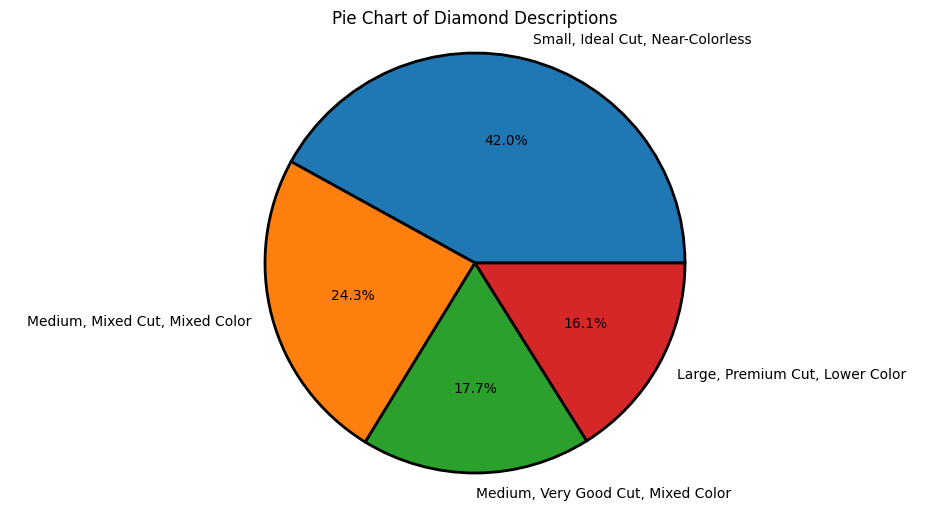

In [133]:
# Distribution of diamond descriptions

dd_val_counts = X['diamond_description'].value_counts()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(np.unique(X['diamond_description']))]
sizes = dd_val_counts.values
labels = dd_val_counts.index

plt.figure(figsize=(12, 6))
plt.title('Pie Chart of Diamond Descriptions')
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.axis('equal')
plt.show()